1.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

2.

In [2]:
churn_df = pd.read_csv('employee_churn.csv')

3.

<Axes: xlabel='department', ylabel='work_life_balance'>

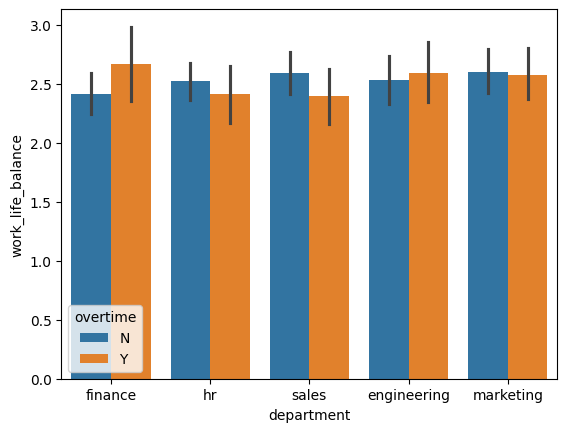

In [3]:
sns.barplot(data=churn_df, x='department', y='work_life_balance', hue='overtime')

In [ ]:
답03 = '2'

4.

In [4]:
churn_df.isna().sum()

,0
years_experience,44
salary,44
education_level,0
department,0
overtime,0
job_satisfaction,0
work_life_balance,0
attrition,0


In [ ]:
답04 = 'years_experience, salary'

In [5]:
pre_df = churn_df.dropna(subset=['years_experience', 'salary'])
pre_df.reset_index(drop=True, inplace=True)

5.

In [6]:
pre_df.groupby(['department'])['job_satisfaction'].mean()

,job_satisfaction
department,
engineering,2.487047
finance,2.558252
hr,2.563877
marketing,2.600000
sales,2.505051


In [ ]:
답05 = '4'

6.

In [7]:
pd.crosstab(pre_df['department'], pre_df['attrition'], normalize='index').round(2)

attrition,0,1
department,,
engineering,0.61,0.39
finance,0.67,0.33
hr,0.66,0.34
marketing,0.69,0.31
sales,0.73,0.27


In [ ]:
답06 = 'engineering'

7.

In [8]:
edu_map = {
    'high_school': 0,
    'bachelor': 1,
    'master': 2,
    'phd': 3
}
pre_df['education_level'] = pre_df['education_level'].map(edu_map)

/tmp/ipykernel_540/1243971406.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre_df['education_level'] = pre_df['education_level'].map(edu_map)


In [9]:
encoding_df = pd.get_dummies(data=pre_df, columns=['department'], drop_first=True)

encoding_df['overtime'] = np.where(encoding_df['overtime'] == 'Y', 1, 0)

8.

In [10]:
X = encoding_df.drop(columns=['attrition'])
y = encoding_df['attrition']

9.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

10.

In [12]:
from sklearn.preprocessing import StandardScaler

In [13]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_valid)

11.

In [14]:
from lightgbm import LGBMClassifier

In [15]:
lgbmc = LGBMClassifier(n_estimators=100, max_depth=6, learning_rate = 0.01, random_state=10)

lgbmc.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 269, number of negative: 542
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000319 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 448
[LightGBM] [Info] Number of data points in the train set: 811, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.331689 -> initscore=-0.700555
[LightGBM] [Info] Start training from score -0.700555
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

LGBMClassifier(learning_rate=0.01, max_depth=6, random_state=10)

12.

In [16]:
from xgboost import XGBClassifier

In [17]:
xgbc = XGBClassifier(n_estimators=200, max_depth=8, learning_rate=0.1, random_state=10)

xgbc.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, ...)

13.

In [18]:
from sklearn.metrics import accuracy_score, f1_score

In [20]:
lgbmc_predict = lgbmc.predict(X_test)
xgbc_predict = xgbc.predict(X_test)

print('LGBMC')
print('ACC :', accuracy_score(y_valid, lgbmc_predict))
print('F1 :', f1_score(y_valid, lgbmc_predict))

print('XGBC')
print('ACC :', accuracy_score(y_valid, xgbc_predict))
print('F1 :', f1_score(y_valid, xgbc_predict))

LGBMC
ACC : 0.6748768472906403
F1 : 0.029411764705882353
XGBC
ACC : 0.5911330049261084
F1 : 0.25225225225225223


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


14.

In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.utils import to_categorical

tf.random.set_seed(10)
y_train = to_categorical(y_train, num_classes=2)
y_valid = to_categorical(y_valid, num_classes=2)

In [25]:
model = Sequential()
model.add(Dense(64, activation='selu', input_shape=(X_train.shape[1],)))
model.add(BatchNormalization())
model.add(Dense(32, activation='selu'))
model.add(BatchNormalization())
model.add(Dense(16, activation='selu'))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.fit(X_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5487 - loss: 0.7235
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6178 - loss: 0.6577
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6326 - loss: 0.6370
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6523 - loss: 0.6260
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6597 - loss: 0.6176
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6695 - loss: 0.6106
Epoch 7/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6745 - loss: 0.6052
Epoch 8/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6806 - loss: 0.5998
Epoch 9/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6856 - loss: 0.5953
Epoch 10/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6893 - loss: 0.5909
Epoch 11/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6942 - loss: 0.5873
Epoch 12/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6991 - lo